In [1]:
import pandas as pd
import json
import time
from tqdm import tqdm
from openai import OpenAI

# ================================
# CONFIG
# ================================
INPUT_PATH = "/Users/sushildalavi/Desktop/NLC/BBNaija/MIH_S2 YT Final Topic Relevant Comments.xlsx"
THEME_SOURCE_PATH = "/Users/sushildalavi/Desktop/NLC/BBNaija/MIH_S2 for LLM Coding.xlsx"
OUTPUT_PATH = "/Users/sushildalavi/Desktop/NLC/BBNaija/MIH_S2_Final_LABELED.xlsx"

MODEL_NAME = "gpt-5.1"
SLEEP_BETWEEN_CALLS = 0.3

# ================================
# LOAD DATA
# ================================
df = pd.read_excel(INPUT_PATH)

# robust comment column detection
def find_comment_col(df):
    for c in df.columns:
        if str(c).lower().strip() in ["comment", "comments", "text", "comment text", "content"]:
            return c
    raise ValueError("No comment column found")

COMMENT_COL = find_comment_col(df)
df["comment"] = df[COMMENT_COL].astype(str)

# ================================
# MIH CANONICAL THEMES (FROM DATASET)
# ================================
MIH_THEMES = [
    "India Local Culture",
    "Gender Norms & Dynamics",
    "Gender-Based Violence",
    "Economic Empowerment",
    "Caste / Intersectionality",
    "Body & Beauty Standards",
]

# ================================
# OPENAI CLIENT
# ================================
client = OpenAI()

# ================================
# PROMPT
# ================================
SYSTEM_PROMPT = """
You are a social science coding assistant.

Your task is to label a YouTube comment using ONLY the provided theme list and sentiment labels.

Rules:
- Assign ZERO OR MORE themes from the list.
- Do NOT invent new themes.
- Sentiment must be exactly one of: Positive, Neutral, Negative.
- Output must be valid JSON only.
"""

def build_user_prompt(comment: str) -> str:
    return f"""
Theme list:
{json.dumps(MIH_THEMES, indent=2)}

Sentiment options:
["Positive", "Neutral", "Negative"]

Comment:
\"\"\"{comment}\"\"\"

Return JSON in this exact format:
{{
  "themes": ["theme1", "theme2"],
  "sentiment": "Positive | Neutral | Negative"
}}
"""

# ================================
# LLM CALL
# ================================
def label_comment(comment: str):
    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            temperature=0,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": build_user_prompt(comment)},
            ],
        )

        content = response.choices[0].message.content.strip()
        parsed = json.loads(content)

        themes = parsed.get("themes", [])
        sentiment = parsed.get("sentiment", None)

        # strict validation
        themes = [t for t in themes if t in MIH_THEMES]
        if sentiment not in ["Positive", "Neutral", "Negative"]:
            sentiment = None

        return "; ".join(themes), sentiment

    except Exception as e:
        return "", None

# ================================
# RUN LABELING
# ================================
themes_out = []
sentiments_out = []

for comment in tqdm(df["comment"], desc="Labeling MIH comments"):
    themes, sentiment = label_comment(comment)
    themes_out.append(themes)
    sentiments_out.append(sentiment)
    time.sleep(SLEEP_BETWEEN_CALLS)

df["themes"] = themes_out
df["sentiment"] = sentiments_out

# ================================
# SAVE
# ================================
out = df[["comment", "themes", "sentiment"]].copy()
out.to_excel(OUTPUT_PATH, index=False)

print("✅ MIH labeling complete")
print("Saved to:", OUTPUT_PATH)
print("\nTheme counts:")
print(out["themes"].str.split("; ").explode().value_counts())
print("\nSentiment counts:")
print(out["sentiment"].value_counts(dropna=False))

Labeling MIH comments: 100%|██████████| 951/951 [20:23<00:00,  1.29s/it]

✅ MIH labeling complete
Saved to: /Users/sushildalavi/Desktop/NLC/BBNaija/MIH_S2_Final_LABELED.xlsx

Theme counts:
themes
                             431
Gender Norms & Dynamics      349
Caste / Intersectionality    129
India Local Culture          125
Body & Beauty Standards       85
Economic Empowerment          75
Gender-Based Violence         63
Name: count, dtype: int64

Sentiment counts:
sentiment
Negative    645
Positive    178
Neutral     128
Name: count, dtype: int64



[Made in Heaven S2 — Full Topic-Relevant] detected columns:
  comment   -> comment
  themes    -> themes
  sentiment -> sentiment

[Made in Heaven S2 — LLM Coding] detected columns:
  comment   -> Comment Text
  themes    -> Themes
  sentiment -> Sentiment

=== THEME DIAGNOSTICS: Made in Heaven S2 Full Topic-Relevant ===
Rows: 951
Rows with NO themes (after parsing): 431
Total theme tags (after parsing): 826

Canonical theme coverage:
theme_list
Gender Norms & Dynamics      349
India Local Culture          125
Caste / Intersectionality    129
Body & Beauty Standards       85
Gender-Based Violence         63
Economic Empowerment          75
Name: count, dtype: int64

✅ All themes map cleanly to canonical list (or are empty).

=== THEME DIAGNOSTICS: Made in Heaven S2 LLM Coding ===
Rows: 102
Rows with NO themes (after parsing): 0
Total theme tags (after parsing): 102

Canonical theme coverage:
theme_list
Gender Norms & Dynamics      44
India Local Culture          14
Caste / Intersectio

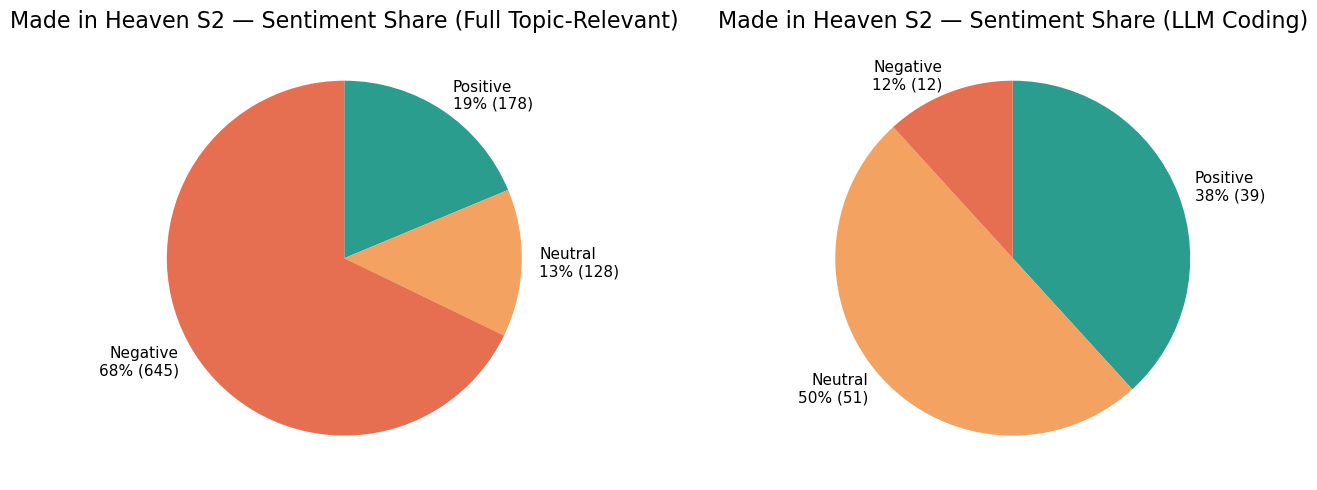

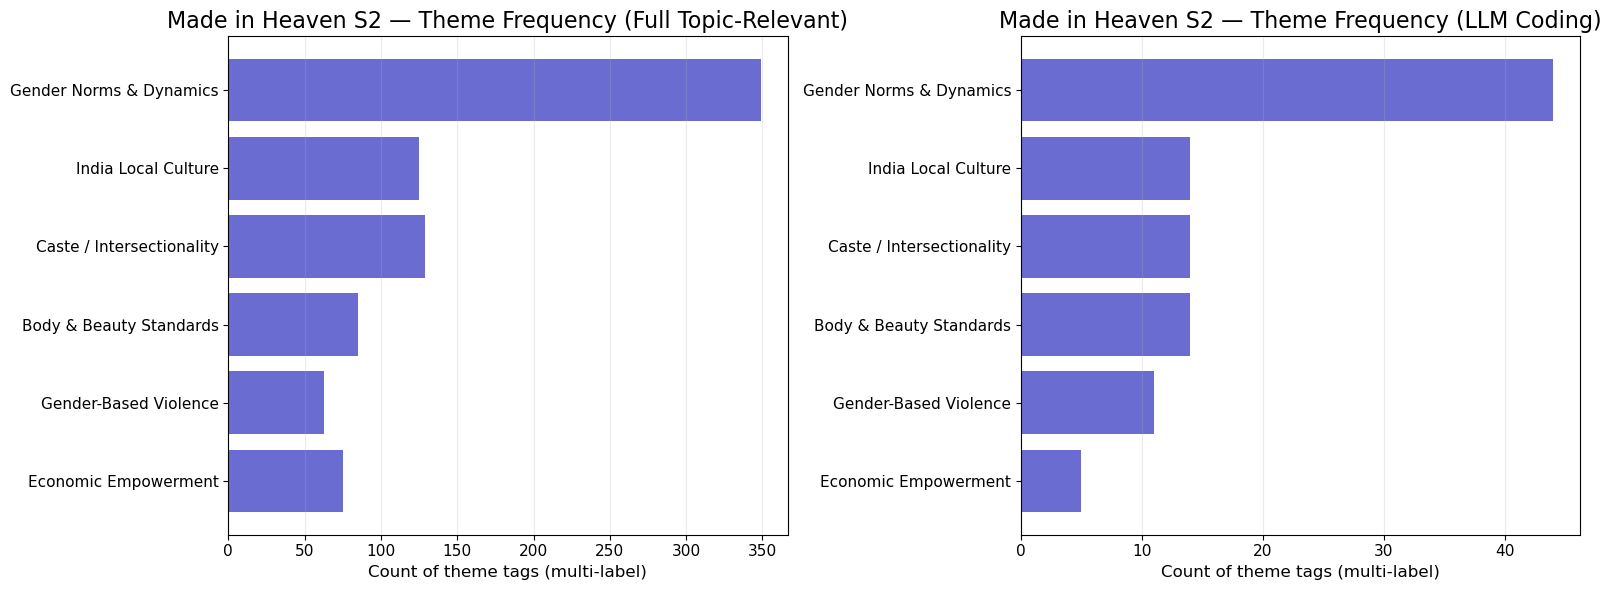

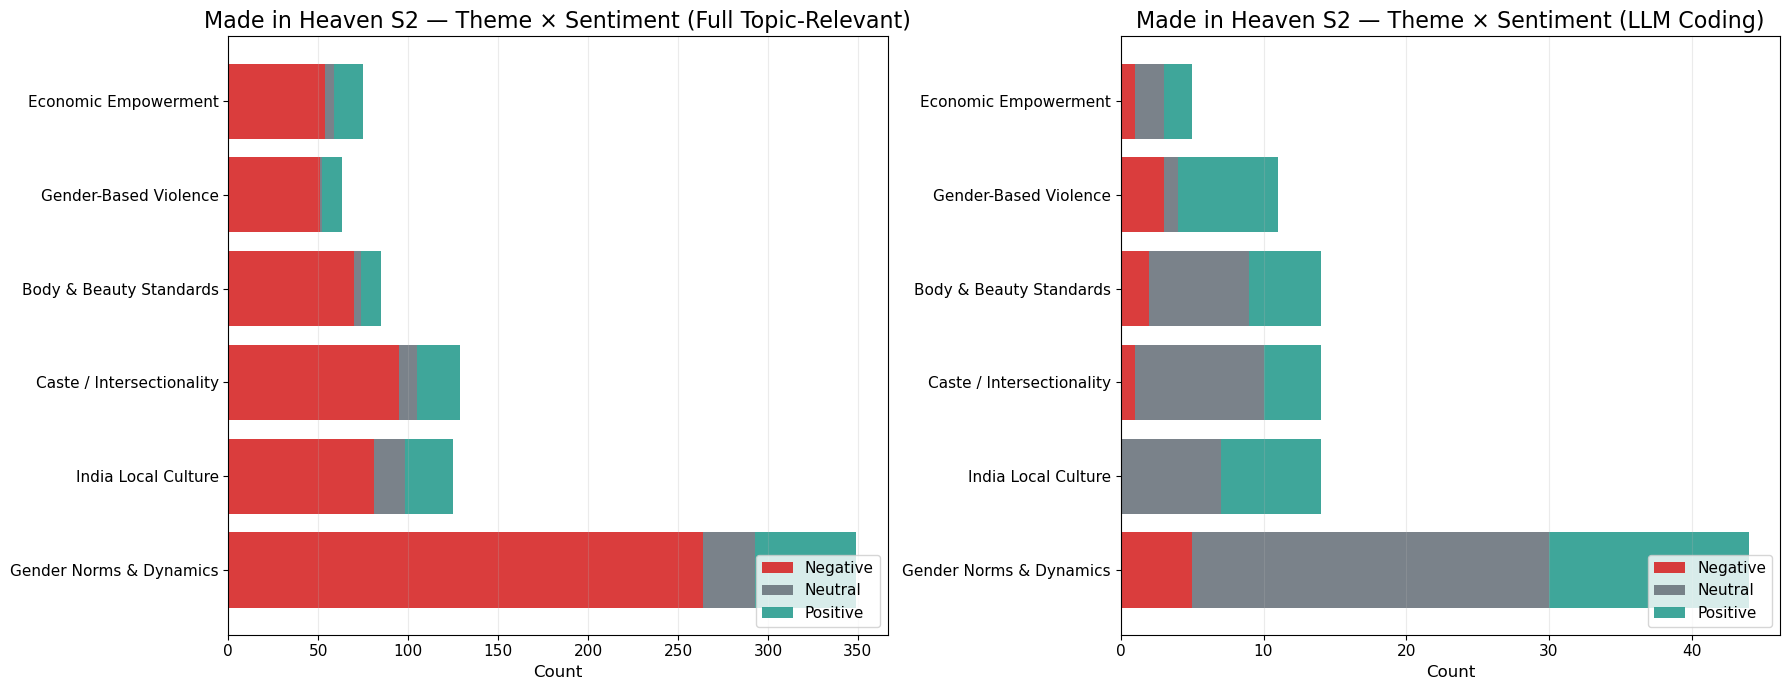

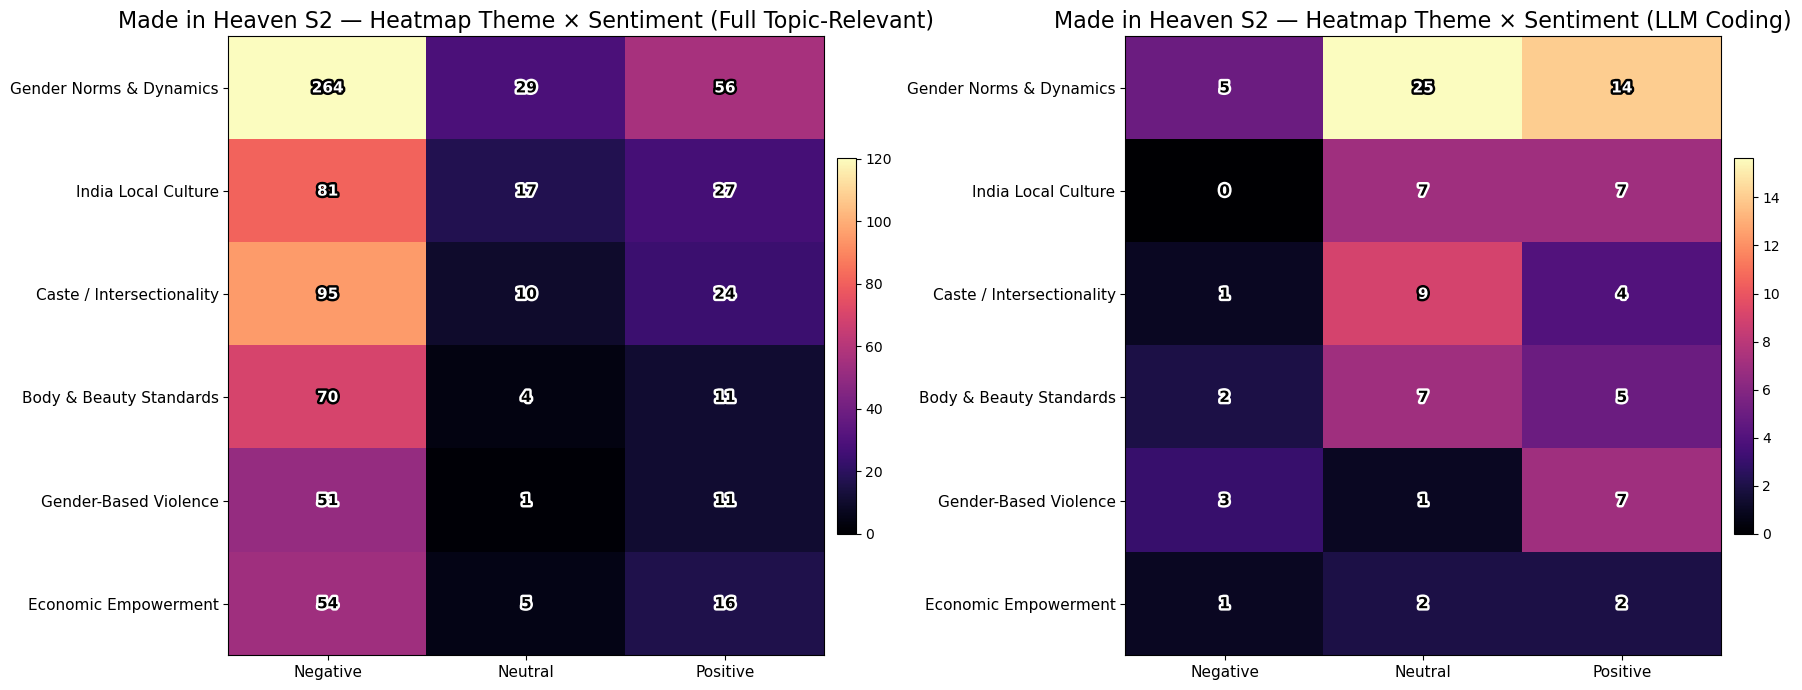


[BBNaija S9 — Full Topic-Relevant] detected columns:
  comment   -> comment
  themes    -> themes
  sentiment -> sentiment

[BBNaija S9 — LLM Coding] detected columns:
  comment   -> Comment Text
  themes    -> Themes
  sentiment -> Sentiment

=== THEME DIAGNOSTICS: BBNaija S9 Full Topic-Relevant ===
Rows: 922
Rows with NO themes (after parsing): 0
Total theme tags (after parsing): 2384

Canonical theme coverage:
theme_list
Participation, Competition, and Influence      310
Marriage, Relationships, and Loyalty Norms     366
Sexuality and Respectability Policing           96
Moral Judgment and Character Evaluation        476
Gender Norms and Gender Double Standards       177
Conflict, Insults, and Humiliation Dynamics    152
Sexist or Derogatory Language                  130
Emotional Expression                           562
Behavioral Responses and Engagement            115
Name: count, dtype: int64

✅ All themes map cleanly to canonical list (or are empty).

=== THEME DIAGNOSTICS: BB

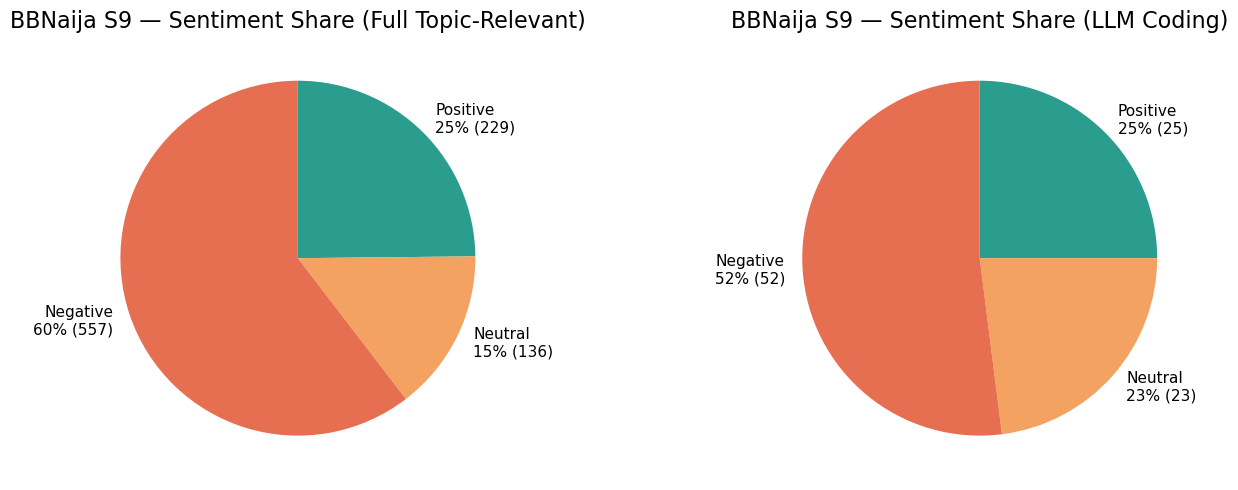

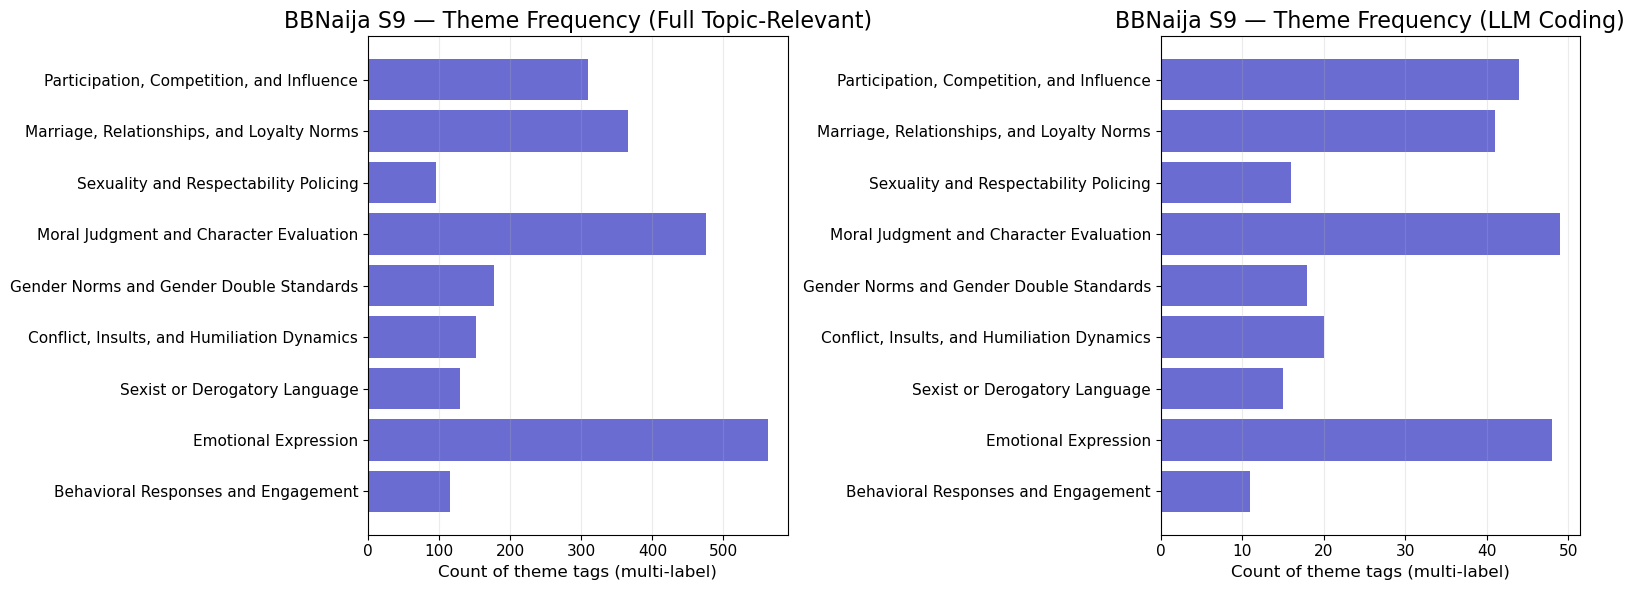

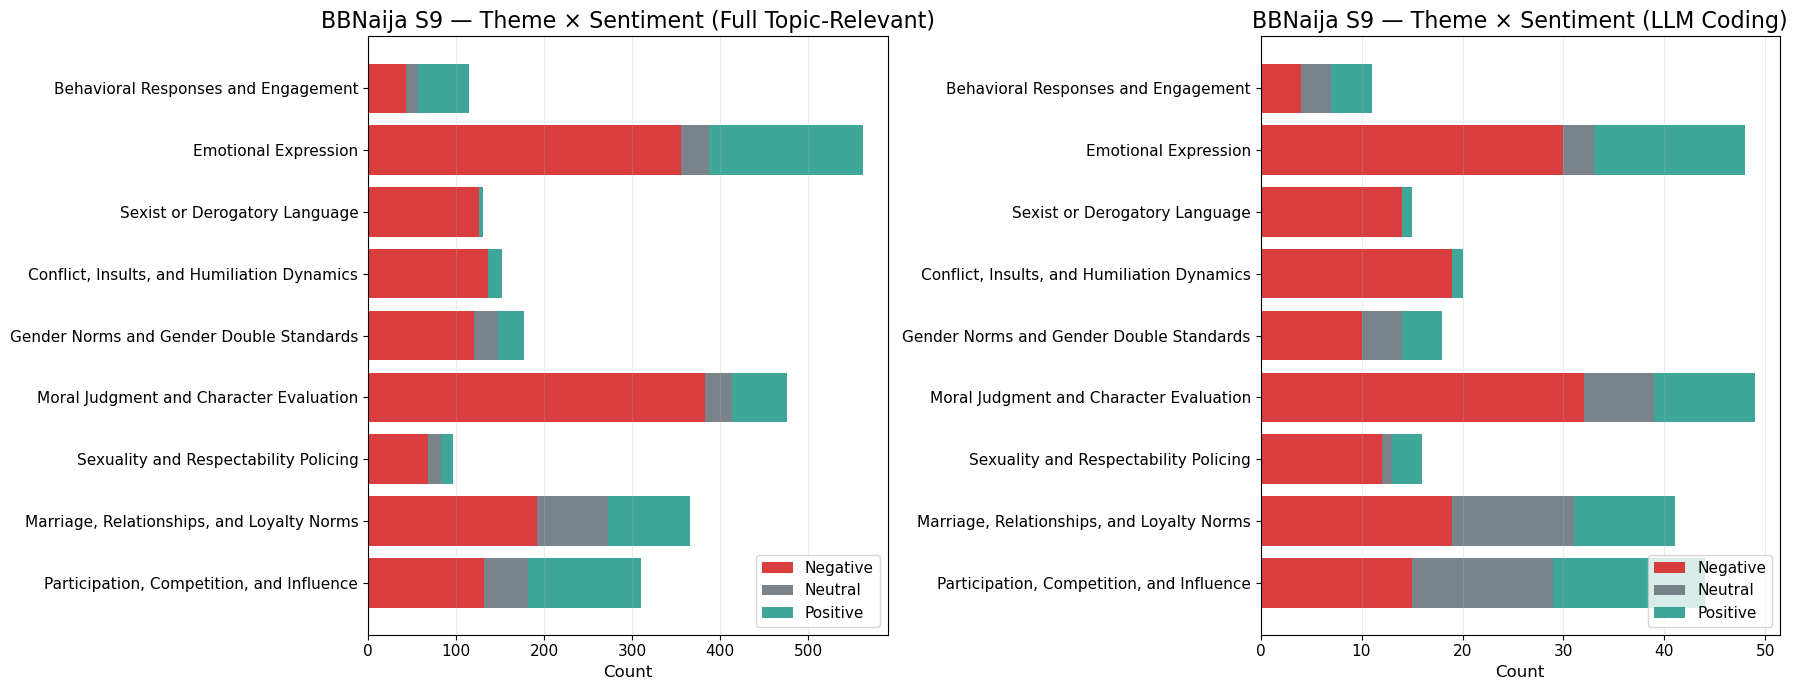

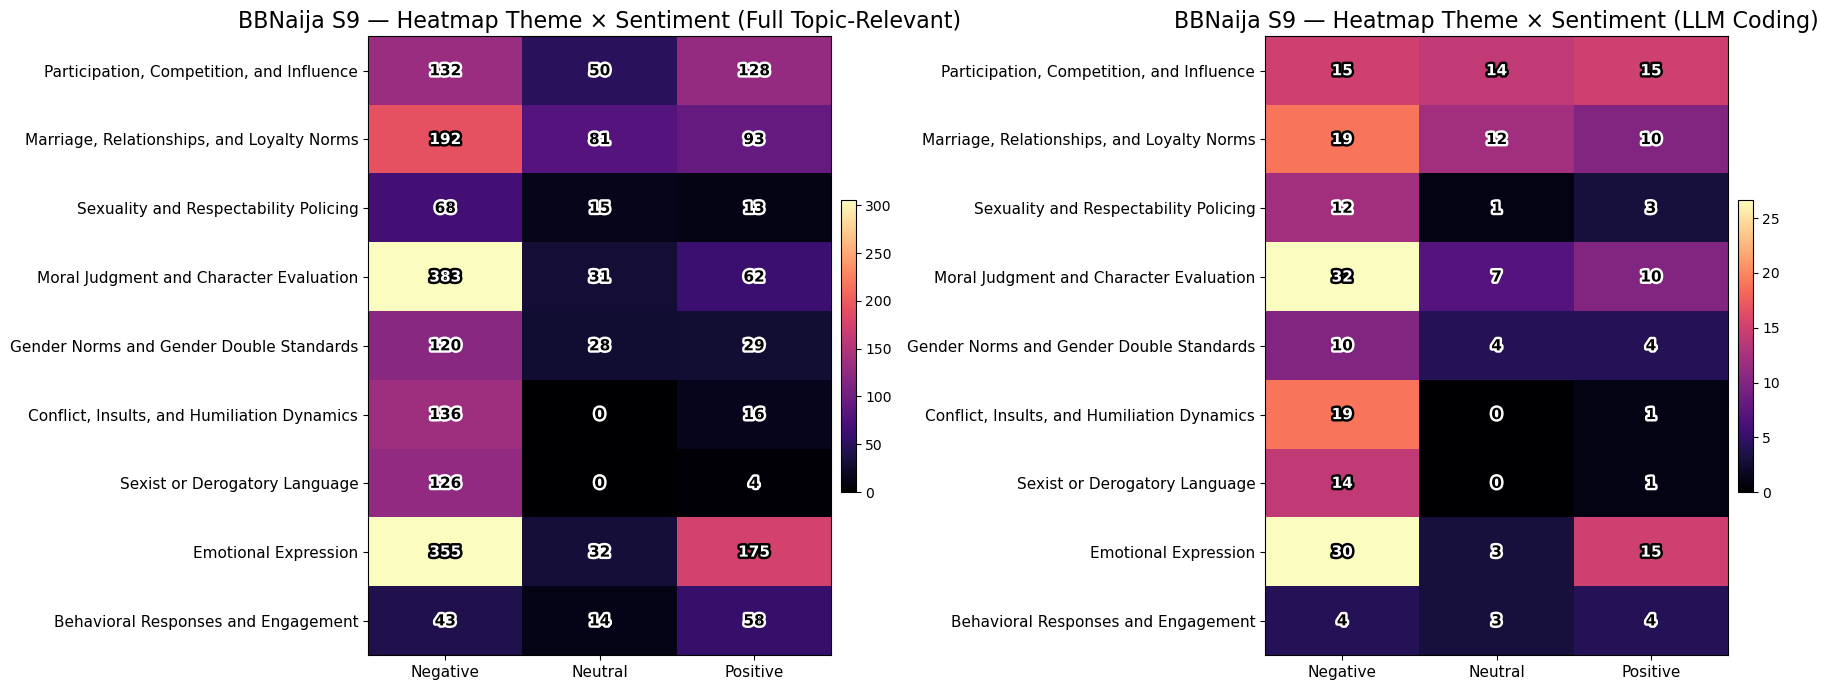

In [3]:
# ============================================================
# PRO-QUALITY VIZ (INLINE) + THEME CONSISTENCY CHECK
# FIXED THEME PARSING: DO NOT SPLIT ON COMMAS
# (themes are separated by ; | or newline — commas are part of theme names)
#
# ✅ Works for BBNaija + MIH using your provided paths
# ✅ Robust column detection (no KeyError)
# ✅ Canonicalizes themes to YOUR theme list (exact + fuzzy + substring)
# ✅ Drops NaNs cleanly before plotting
# ✅ Heatmap won't crash (forces int matrix)
# ✅ 4 figures total (same as RHON)
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from difflib import get_close_matches
import matplotlib.patheffects as pe

# -----------------------------
# PATHS (LOCAL)
# -----------------------------
PATH_BB_FULL = "/Users/sushildalavi/Desktop/NLC/BBNaija/BBNaija_Final Topic Relevant.xlsx"
PATH_BB_LLM  = "/Users/sushildalavi/Desktop/NLC/BBNaija/BBNaija for LLM Coding.xlsx"

PATH_MIH_FULL = "/Users/sushildalavi/Desktop/NLC/BBNaija/MIH_S2_Final_LABELED.xlsx"
PATH_MIH_LLM  = "/Users/sushildalavi/Desktop/NLC/BBNaija/MIH_S2 for LLM Coding.xlsx"

# -----------------------------
# CANONICAL THEMES — BBNaija
# -----------------------------
BB_CANON_THEMES = [
    "Participation, Competition, and Influence",
    "Marriage, Relationships, and Loyalty Norms",
    "Sexuality and Respectability Policing",
    "Moral Judgment and Character Evaluation",
    "Gender Norms and Gender Double Standards",
    "Conflict, Insults, and Humiliation Dynamics",
    "Sexist or Derogatory Language",
    "Emotional Expression",
    "Behavioral Responses and Engagement",
]

# -----------------------------
# CANONICAL THEMES — MIH
# (use only what actually appears in your files; add SRH/Emotional States only if you truly label them)
# -----------------------------
MIH_CANON_THEMES = [
    "Gender Norms & Dynamics",
    "India Local Culture",
    "Caste / Intersectionality",
    "Body & Beauty Standards",
    "Gender-Based Violence",
    "Economic Empowerment",
    # If your LLM ever outputs these later, add them back:
    # "Sexual & Reproductive Health",
    # "Emotional States",
]

SENTIMENT_ALLOWED = {"Positive", "Neutral", "Negative"}
SENTIMENT_ORDER   = ["Negative", "Neutral", "Positive"]

# -----------------------------
# LOAD
# -----------------------------
def load_xlsx(path: str) -> pd.DataFrame:
    return pd.read_excel(path)

# -----------------------------
# COLUMN DETECTION (robust)
# -----------------------------
def detect_col(df: pd.DataFrame, kind: str) -> str | None:
    cols = list(df.columns)
    lcols = {str(c).lower().strip(): c for c in cols}

    if kind == "comment":
        candidates = [
            "comment", "comments", "comment text", "text", "body", "content",
            "message", "raw_text", "raw text", "post", "tweet"
        ]
        for k in candidates:
            if k in lcols:
                return lcols[k]
        # fallback: longest object column by median length
        obj = [c for c in cols if df[c].dtype == "object"]
        if not obj:
            raise ValueError(f"No text-like column found for comments. Columns: {cols}")
        med_len = {c: df[c].dropna().astype(str).str.len().median() for c in obj}
        return max(med_len, key=med_len.get)

    if kind == "themes":
        candidates = ["themes", "theme", "topic", "topics", "labels", "label", "final themes"]
        for k in candidates:
            if k in lcols:
                return lcols[k]
        return None

    if kind == "sentiment":
        candidates = ["sentiment", "polarity", "final sentiment", "sentiment label"]
        for k in candidates:
            if k in lcols:
                return lcols[k]
        return None

    return None

# -----------------------------
# THEME CLEANING (CRITICAL FIX: DO NOT SPLIT ON COMMAS)
# -----------------------------
def split_themes(cell) -> list[str]:
    """
    Correct behavior for your files:
    - Multi-label themes are separated by ';' (or sometimes '|' or newlines).
    - Theme NAMES contain commas -> NEVER split on comma.
    """
    if pd.isna(cell):
        return []
    s = str(cell).strip()
    if not s:
        return []

    # normalize separators into semicolons
    if any(sep in s for sep in [";", "|", "\n"]):
        s = s.replace("\n", ";").replace("|", ";")
        parts = [p.strip() for p in s.split(";") if p.strip()]
    else:
        # no explicit multi-theme delimiter -> treat as ONE theme string
        parts = [s]

    out = []
    for t in parts:
        t = re.sub(r"^\s*and\s+", "", t, flags=re.IGNORECASE).strip()
        t = re.sub(r"\s+", " ", t).strip()
        if t:
            out.append(t)

    # dedupe preserve order
    seen = set()
    dedup = []
    for t in out:
        if t not in seen:
            seen.add(t)
            dedup.append(t)
    return dedup

def canonicalize_theme(t: str, canon_themes: list[str]) -> str:
    if not t:
        return t

    # exact (case-insensitive)
    for c in canon_themes:
        if t.lower() == c.lower():
            return c

    t2 = t.strip().strip(".").strip()

    # substring hint
    for c in canon_themes:
        if t2.lower() in c.lower() or c.lower() in t2.lower():
            return c

    # fuzzy match
    m = get_close_matches(t2, canon_themes, n=1, cutoff=0.74)
    if m:
        return m[0]

    return t2

def normalize_sentiment(x) -> str | float:
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if not s:
        return np.nan
    s2 = s.lower()
    if s2 == "positive": return "Positive"
    if s2 == "negative": return "Negative"
    if s2 == "neutral":  return "Neutral"
    return np.nan

def standardize(df: pd.DataFrame, name: str, canon_themes: list[str]) -> pd.DataFrame:
    df = df.copy()

    c_col = detect_col(df, "comment")
    t_col = detect_col(df, "themes")
    s_col = detect_col(df, "sentiment")

    df["comment"] = df[c_col].astype(str)
    df = df[df["comment"].str.strip() != ""].copy()

    # themes
    df["themes_raw"] = df[t_col] if t_col is not None else np.nan
    df["theme_list_raw"] = df["themes_raw"].apply(split_themes)
    df["theme_list"] = df["theme_list_raw"].apply(lambda L: [canonicalize_theme(x, canon_themes) for x in L])

    # sentiment
    df["sentiment"] = df[s_col].apply(normalize_sentiment) if s_col is not None else np.nan

    df["_source"] = name

    print(f"\n[{name}] detected columns:")
    print(f"  comment   -> {c_col}")
    print(f"  themes    -> {t_col if t_col else 'NOT FOUND'}")
    print(f"  sentiment -> {s_col if s_col else 'NOT FOUND'}")

    return df

# -----------------------------
# DIAGNOSTICS
# -----------------------------
def theme_diagnostics(df: pd.DataFrame, label: str, canon_themes: list[str]):
    exploded = df["theme_list"].explode().dropna().astype(str)
    canon = exploded[exploded.isin(canon_themes)]
    unknown = exploded[~exploded.isin(canon_themes)]

    print(f"\n=== THEME DIAGNOSTICS: {label} ===")
    print(f"Rows: {len(df)}")
    print(f"Rows with NO themes (after parsing): {(df['theme_list'].apply(len)==0).sum()}")
    print(f"Total theme tags (after parsing): {len(exploded)}")
    print("\nCanonical theme coverage:")
    print(canon.value_counts().reindex(canon_themes).fillna(0).astype(int))

    if len(unknown) > 0:
        print("\n⚠️ Non-canonical theme strings found (top 30):")
        print(unknown.value_counts().head(30))
    else:
        print("\n✅ All themes map cleanly to canonical list (or are empty).")

def sentiment_diagnostics(df: pd.DataFrame, label: str):
    s = df["sentiment"]
    print(f"\n=== SENTIMENT DIAGNOSTICS: {label} ===")
    print("Valid sentiment counts:")
    print(s[s.isin(SENTIMENT_ALLOWED)].value_counts().reindex(["Positive","Neutral","Negative"]).fillna(0).astype(int))
    print("Missing/invalid sentiment rows:", int(s.isna().sum()))

# -----------------------------
# EXPLODE THEMES FOR MULTI-LABEL PLOTS
# -----------------------------
def explode_themes(df: pd.DataFrame, canon_themes: list[str]) -> pd.DataFrame:
    x = df.copy().explode("theme_list").rename(columns={"theme_list": "theme"})
    x["theme"] = x["theme"].astype(str)
    x = x[~x["theme"].isna()].copy()
    x = x[x["theme"].isin(canon_themes)].copy()
    return x

# -----------------------------
# STYLE (same vibe as your RHON notebook)
# -----------------------------
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})

PIE_COLORS    = ["#2A9D8F", "#F4A261", "#E76F51"]   # Positive, Neutral, Negative
BAR_COLOR     = "#5E60CE"
STACK_COLORS  = {"Negative": "#D62828", "Neutral": "#6C757D", "Positive": "#2A9D8F"}
HEATMAP_CMAP  = "magma"

# -----------------------------
# PLOTS
# -----------------------------
def sentiment_pie(ax, df: pd.DataFrame, title: str):
    s = df["sentiment"].dropna()
    s = s[s.isin(SENTIMENT_ALLOWED)]
    counts = s.value_counts().reindex(["Positive", "Neutral", "Negative"]).fillna(0).astype(int)
    total = int(counts.sum())

    ax.set_title(title)
    if total == 0:
        ax.text(0.5, 0.5, "No sentiment data in this file", ha="center", va="center")
        return

    labels = [f"{k}\n{(v/total*100):.0f}% ({v})" for k, v in counts.items()]
    ax.pie(counts.values, labels=labels, startangle=90, counterclock=False, colors=PIE_COLORS)

def theme_bar(ax, df_e: pd.DataFrame, canon_themes: list[str], title: str):
    c = df_e["theme"].value_counts().reindex(canon_themes).fillna(0).astype(int)
    ax.barh(c.index[::-1], c.values[::-1], color=BAR_COLOR, alpha=0.92)
    ax.set_title(title)
    ax.set_xlabel("Count of theme tags (multi-label)")
    ax.grid(axis="x", alpha=0.25)

def stacked_theme_sentiment(ax, df_e: pd.DataFrame, canon_themes: list[str], title: str):
    d = df_e.dropna(subset=["sentiment"]).copy()
    d = d[d["sentiment"].isin(SENTIMENT_ALLOWED)]
    ax.set_title(title)

    if len(d) == 0:
        ax.text(0.5, 0.5, "No sentiment data in this file", ha="center", va="center")
        return

    pivot = (
        d.groupby(["theme", "sentiment"])
         .size()
         .unstack(fill_value=0)
         .reindex(canon_themes)
         .reindex(columns=SENTIMENT_ORDER)
         .fillna(0)
         .astype(int)
    )

    left = np.zeros(len(pivot))
    for col in pivot.columns:
        ax.barh(
            pivot.index,
            pivot[col].values,
            left=left,
            label=col,
            color=STACK_COLORS[col],
            alpha=0.9
        )
        left += pivot[col].values

    ax.set_xlabel("Count")
    ax.grid(axis="x", alpha=0.25)
    ax.legend(loc="lower right", frameon=True)

def heatmap_theme_sentiment(ax, df_e: pd.DataFrame, canon_themes: list[str], title: str):
    d = df_e.dropna(subset=["sentiment"]).copy()
    d = d[d["sentiment"].isin(SENTIMENT_ALLOWED)]
    ax.set_title(title)

    if len(d) == 0:
        ax.text(0.5, 0.5, "No sentiment data in this file", ha="center", va="center")
        return

    M = (
        d.groupby(["theme", "sentiment"])
         .size()
         .unstack(fill_value=0)
         .reindex(canon_themes)
         .reindex(columns=SENTIMENT_ORDER)
         .fillna(0)
         .astype(int)
    )

    vals = M.values.flatten()
    vmax = np.percentile(vals, 95) if vals.size else 1
    vmax = max(float(vmax), 1.0)

    im = ax.imshow(M.values, aspect="auto", cmap=HEATMAP_CMAP, vmin=0, vmax=vmax)

    ax.set_yticks(range(len(M.index)))
    ax.set_yticklabels(M.index)
    ax.set_xticks(range(len(M.columns)))
    ax.set_xticklabels(M.columns)

    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            val = int(M.iloc[i, j])
            norm_val = (val / vmax) if vmax else 0.0
            txt_color = "white" if norm_val >= 0.45 else "black"
            outline = "black" if txt_color == "white" else "white"
            ax.text(
                j, i, f"{val}",
                ha="center", va="center",
                fontsize=11, fontweight="bold",
                color=txt_color,
                path_effects=[pe.withStroke(linewidth=3.5, foreground=outline)]
            )

    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.ax.tick_params(labelsize=10)

# -----------------------------
# RUN ONE CASE (helper)
# -----------------------------
def run_case(case_name: str, path_full: str, path_llm: str, canon_themes: list[str]):
    df_full = standardize(load_xlsx(path_full), f"{case_name} — Full Topic-Relevant", canon_themes)
    df_llm  = standardize(load_xlsx(path_llm),  f"{case_name} — LLM Coding",        canon_themes)

    theme_diagnostics(df_full, f"{case_name} Full Topic-Relevant", canon_themes)
    theme_diagnostics(df_llm,  f"{case_name} LLM Coding",          canon_themes)
    sentiment_diagnostics(df_full, f"{case_name} Full Topic-Relevant")
    sentiment_diagnostics(df_llm,  f"{case_name} LLM Coding")

    df_full_e = explode_themes(df_full, canon_themes)
    df_llm_e  = explode_themes(df_llm,  canon_themes)

    # FIGURE 1: SENTIMENT SHARE
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sentiment_pie(axes[0], df_full, f"{case_name} — Sentiment Share (Full Topic-Relevant)")
    sentiment_pie(axes[1], df_llm,  f"{case_name} — Sentiment Share (LLM Coding)")
    plt.tight_layout()
    plt.show()

    # FIGURE 2: THEME FREQUENCY
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    theme_bar(axes[0], df_full_e, canon_themes, f"{case_name} — Theme Frequency (Full Topic-Relevant)")
    theme_bar(axes[1], df_llm_e,  canon_themes, f"{case_name} — Theme Frequency (LLM Coding)")
    plt.tight_layout()
    plt.show()

    # FIGURE 3: THEME × SENTIMENT (STACKED)
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    stacked_theme_sentiment(axes[0], df_full_e, canon_themes, f"{case_name} — Theme × Sentiment (Full Topic-Relevant)")
    stacked_theme_sentiment(axes[1], df_llm_e,  canon_themes, f"{case_name} — Theme × Sentiment (LLM Coding)")
    plt.tight_layout()
    plt.show()

    # FIGURE 4: HEATMAP THEME × SENTIMENT
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    heatmap_theme_sentiment(axes[0], df_full_e, canon_themes, f"{case_name} — Heatmap Theme × Sentiment (Full Topic-Relevant)")
    heatmap_theme_sentiment(axes[1], df_llm_e,  canon_themes, f"{case_name} — Heatmap Theme × Sentiment (LLM Coding)")
    plt.tight_layout()
    plt.show()

# -----------------------------
# RUN: MIH + BBNaija
# -----------------------------
run_case("Made in Heaven S2", PATH_MIH_FULL, PATH_MIH_LLM, MIH_CANON_THEMES)
run_case("BBNaija S9",        PATH_BB_FULL,  PATH_BB_LLM,  BB_CANON_THEMES)